# 04 — Integração, Correlações e Cálculo Alpha do IPB

**Objetivo**: cruzar todos os pilares, calcular correlações e gerar uma primeira versão do IPB (alpha).

**Inputs**: `data/processed/trusted_municipios_eda.parquet`.

**Outputs**:
- `data/processed/ipb_alpha.parquet`
- `data/processed/reports/ipb_alpha_report.json`
- Figuras de correlação e ranking.

In [1]:
# Imports
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.config import PROCESSED_DATA_DIR
from src.utils.eda import (
    min_max_normalize,
    plot_correlation_heatmap,
    plot_distribution,
    save_figure,
    save_json,
    save_parquet,
    winsorize_series,
)

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

In [2]:
# Leitura
df = pd.read_parquet(PROCESSED_DATA_DIR / "trusted_municipios_eda.parquet")
logger.info("Linhas: %d, Colunas: %d", df.shape[0], df.shape[1])

2026-09-03 12:16:12,549 - INFO - Linhas: 5570, Colunas: 32


## 1. Seleção de variáveis por pilar

In [3]:
variaveis_ipb = {
    "A_capacidade_consumo": ["rendimento_domiciliar_per_capita", "pib_per_capita"],
    "B_dinamismo": ["pix_per_capita_12m"],
    "C_adocao_digital": ["banda_larga_fixa_por_100_hab"],
    "D_gap_bancario": [
        "agencias_por_100k_hab",
        "depositos_per_capita",
        "credito_per_capita",
    ],
    "E_perfil_demografico": [
        "populacao_18_35_pct",
        "populacao_urbana_pct",
        "escolaridade_ensino_medio_pct",
    ],
}

all_vars = [v for lst in variaveis_ipb.values() for v in lst]
logger.info("Variáveis selecionadas: %s", all_vars)

2026-09-03 12:16:12,773 - INFO - Variáveis selecionadas: ['rendimento_domiciliar_per_capita', 'pib_per_capita', 'pix_per_capita_12m', 'banda_larga_fixa_por_100_hab', 'agencias_por_100k_hab', 'depositos_per_capita', 'credito_per_capita', 'populacao_18_35_pct', 'populacao_urbana_pct', 'escolaridade_ensino_medio_pct']


## 2. Winsorização e normalização

In [4]:
df_ipb = df[
    [
        "id_municipio",
        "nome_municipio",
        "sigla_uf",
        "nome_regiao",
        "populacao_total",
        "estrato_populacional",
    ]
].copy()

for pilar, vars_list in variaveis_ipb.items():
    for var in vars_list:
        col_norm = f"{var}_norm"
        df_ipb[col_norm] = min_max_normalize(
            winsorize_series(df[var].fillna(0), lower=0.01, upper=0.99)
        )

logger.info("Normalização concluída. Shape: %s", df_ipb.shape)

2026-09-03 12:16:12,907 - INFO - Normalização concluída. Shape: (5570, 16)


## 3. Inversão do pilar D (gap bancário)

In [5]:
for var in variaveis_ipb["D_gap_bancario"]:
    df_ipb[f"{var}_norm"] = 1 - df_ipb[f"{var}_norm"]

logger.info("Pilar D invertido")

2026-09-03 12:16:12,956 - INFO - Pilar D invertido


## 4. Cálculo dos pilares e do IPB alpha

In [6]:
for pilar, vars_list in variaveis_ipb.items():
    cols = [f"{var}_norm" for var in vars_list]
    df_ipb[pilar] = df_ipb[cols].mean(axis=1)

# Média geométrica dos 5 pilares × 100
pilar_cols = list(variaveis_ipb.keys())
df_ipb["ipb_alpha"] = (df_ipb[pilar_cols].prod(axis=1)) ** (1 / 5) * 100
df_ipb["rank_ipb_alpha"] = (
    df_ipb["ipb_alpha"].rank(ascending=False, method="min").astype(int)
)

logger.info("IPB alpha - média: %.2f, mediana: %.2f", df_ipb["ipb_alpha"].mean(), df_ipb["ipb_alpha"].median())

2026-09-03 12:16:13,011 - INFO - IPB alpha - média: 35.85, mediana: 35.86


## 5. Correlação entre pilares

2026-09-03 12:16:14,567 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/docs/assets/figures/04_correlacao_pilares.png


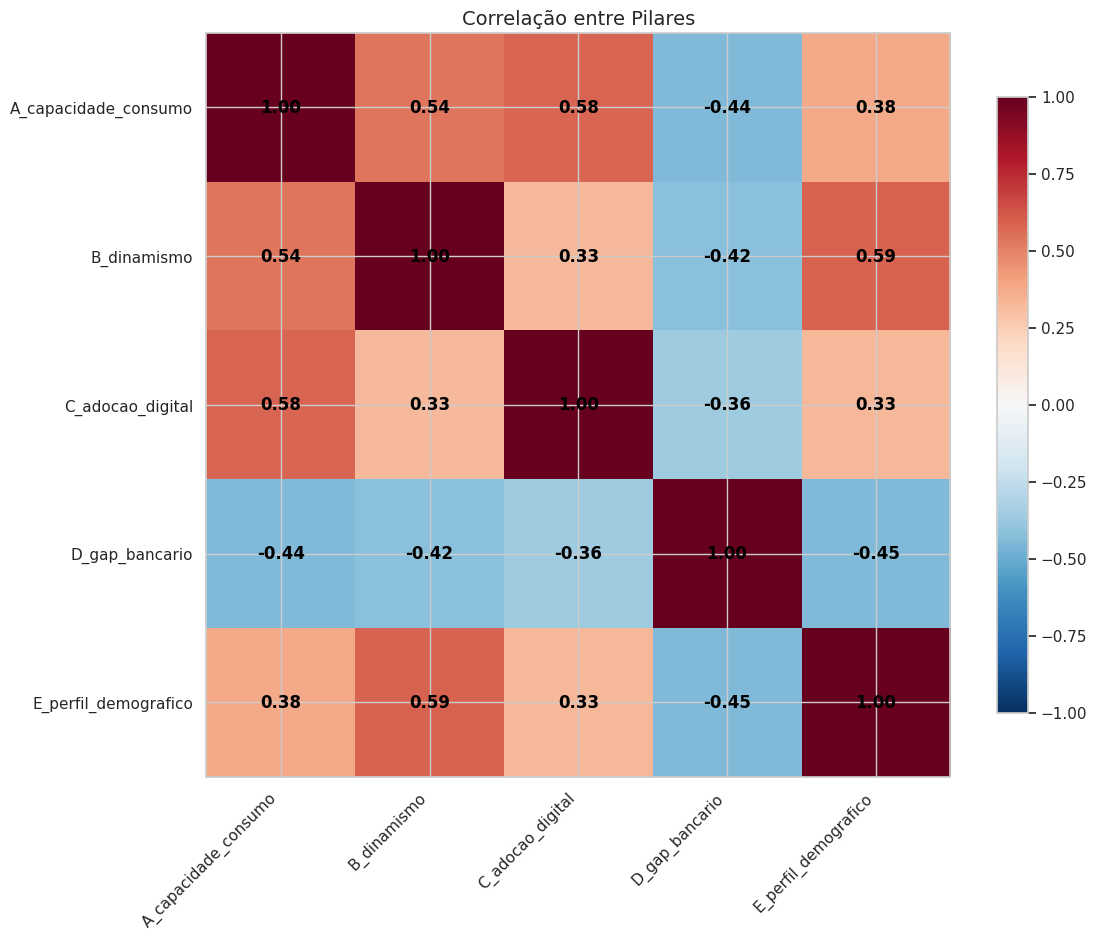

In [7]:
plot_correlation_heatmap(
    df_ipb,
    pilar_cols,
    method="spearman",
    title="Correlação entre Pilares",
    filename="04_correlacao_pilares.png",
)
plt.show()

## 6. Distribuição do IPB alpha

/home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


2026-09-03 12:16:16,636 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/docs/assets/figures/04_dist_ipb_alpha.png


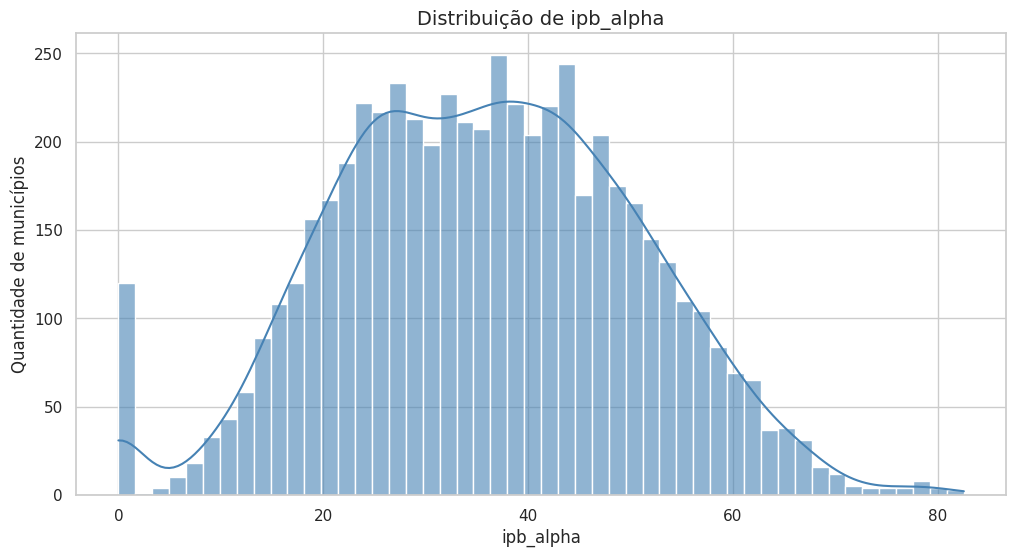

In [8]:
plot_distribution(df_ipb, "ipb_alpha", filename="04_dist_ipb_alpha.png")
plt.show()

## 7. Top e bottom 30 do ranking

In [9]:
top30 = df_ipb.nsmallest(30, "rank_ipb_alpha")[
    ["nome_municipio", "sigla_uf", "ipb_alpha", "rank_ipb_alpha"]
]
bottom30 = df_ipb.nlargest(30, "rank_ipb_alpha")[
    ["nome_municipio", "sigla_uf", "ipb_alpha", "rank_ipb_alpha"]
]

display(top30)
display(bottom30)

,nome_municipio,sigla_uf,ipb_alpha,rank_ipb_alpha
4791,Barueri,SP,82.542855,1
4706,Itapema,SC,82.238545,2
4416,Balneário Camboriú,SC,81.807578,3
5417,Paulínia,SP,80.874712,4
4422,Itajaí,SC,80.047313,5
5353,Ilhabela,SP,79.872347,6
2197,Nova Lima,MG,79.854687,7
5358,Itupeva,SP,79.147183,8
2328,Santa Carmem,MT,78.929170,9
2406,Nova Mutum,MT,78.803611,10


,nome_municipio,sigla_uf,ipb_alpha,rank_ipb_alpha
4,Marechal Thaumaturgo,AC,0.0,5451
7,Santa Rosa do Purus,AC,0.0,5451
44,Feliz Deserto,AL,0.0,5451
69,Palestina,AL,0.0,5451
73,Paulo Jacinto,AL,0.0,5451
74,Piaçabuçu,AL,0.0,5451
78,Porto Real do Colégio,AL,0.0,5451
80,Roteiro,AL,0.0,5451
83,São Brás,AL,0.0,5451
116,Coruripe,AL,0.0,5451


2026-09-03 12:16:18,680 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/docs/assets/figures/04_top30_ipb_alpha.png


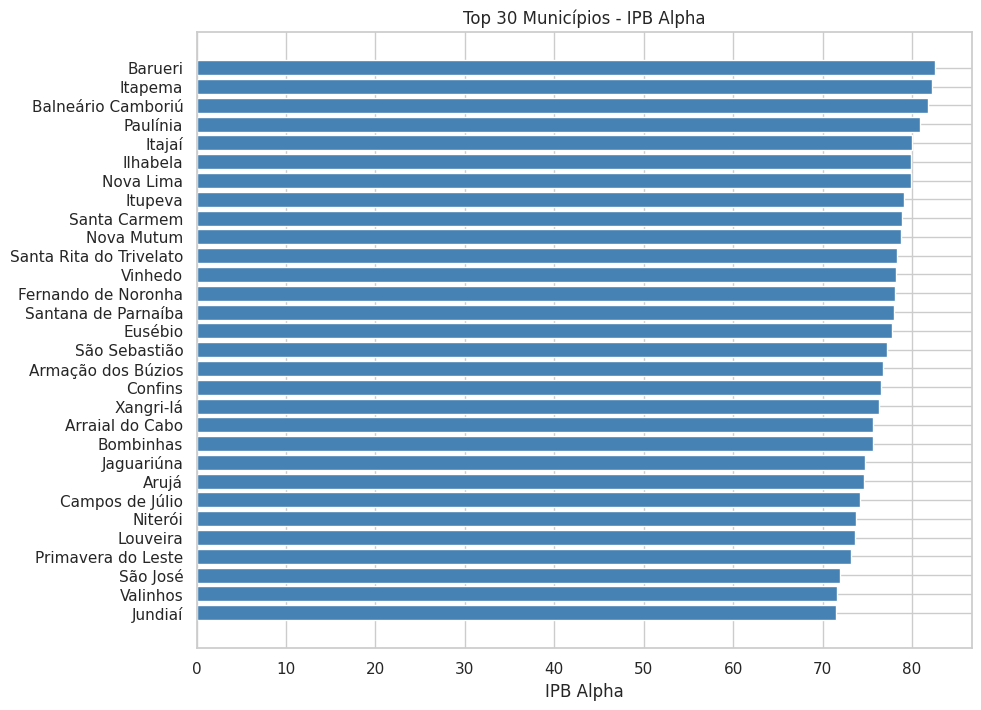

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))
top30_sorted = top30.sort_values("ipb_alpha")
ax.barh(top30_sorted["nome_municipio"], top30_sorted["ipb_alpha"], color="steelblue")
ax.set_title("Top 30 Municípios - IPB Alpha")
ax.set_xlabel("IPB Alpha")
save_figure(fig, "04_top30_ipb_alpha.png")
plt.show()

## 8. Correlação das novas variáveis da V3 (CEMPRE, correspondentes e turismo)

Heatmap de Spearman cruzando as variáveis introduzidas na V3 — empregos formais e unidades locais por 1000 hab. (CEMPRE 2024), unidades de alojamento/alimentação por 1000 hab. (validador de turismo), correspondentes por 100k hab. (brutos e ponderados por tipo), `gap_bancario_completo`, `score_turismo` e `penetracao_digital_relativa` — contra as variáveis base dos pilares (PIB per capita, rendimento domiciliar per capita, Pix per capita, banda larga fixa, agências por 100k hab.) e os scores/IPB/rank da V3. As leituras principais são registradas em `04_correlacao_novas.json` e impressas abaixo.

2026-09-03 12:16:22,020 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/docs/assets/figures/04_correlacao_novas_variaveis.png


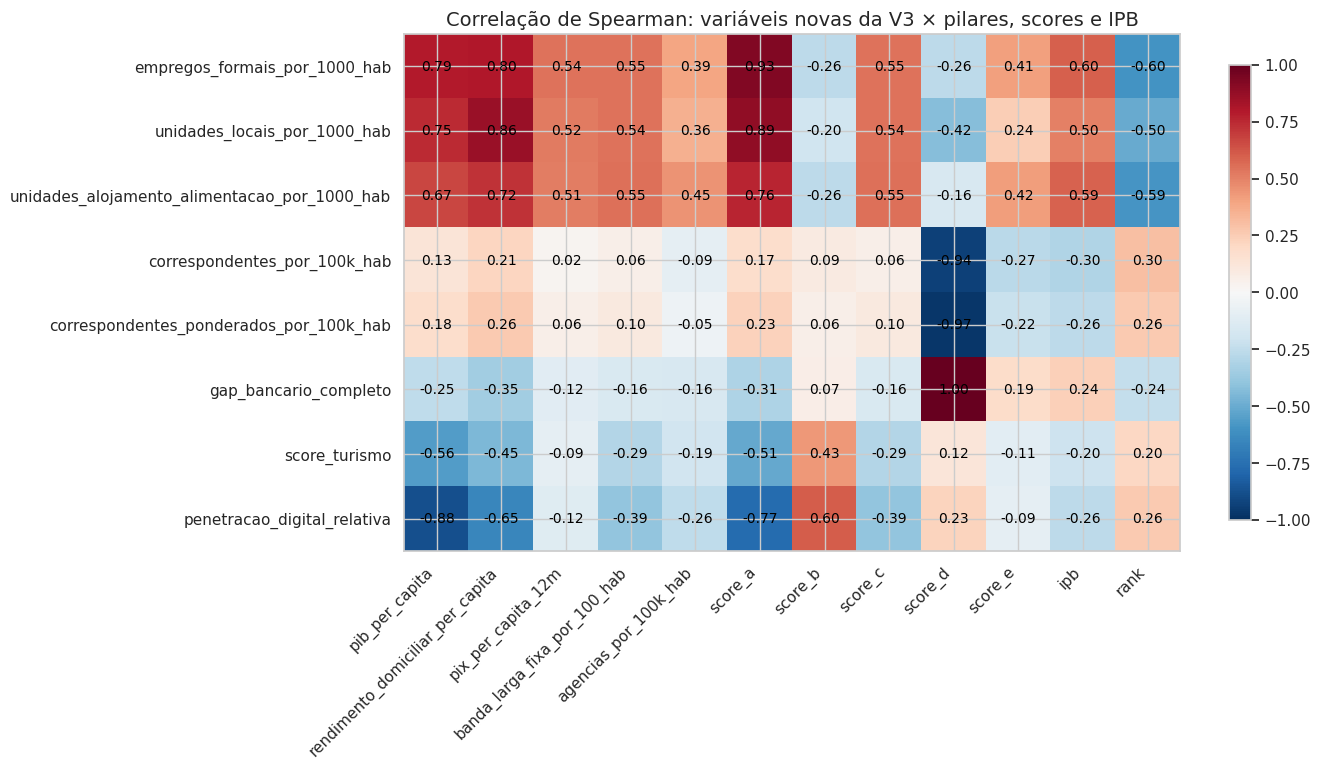

2026-09-03 12:16:23,137 - INFO - JSON salvo em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/reports/04_correlacao_novas.json


2026-09-03 12:16:23,139 - INFO - Leituras principais das novas variáveis:
{'empregos_formais_x_pib_pc': 0.79, 'empregos_formais_x_pix_per_capita': 0.543, 'empregos_formais_x_score_a': 0.927, 'alojamento_alimentacao_x_rank_v3': -0.589, 'correspondentes_x_agencias': -0.092, 'corr_ponderados_x_gap_completo': -0.969, 'score_turismo_x_pib_pc': -0.558, 'penetracao_digital_x_pix_per_capita': -0.124}


In [11]:
# Correlação (Spearman) das variáveis novas da V3 × variáveis base dos pilares e IPB V3
df_v3 = pd.read_parquet(
    PROCESSED_DATA_DIR / "analytics_ipb_v3_presenca_completa.parquet"
)

df_corr_novas = df[
    [
        "id_municipio",
        "pib_per_capita",
        "rendimento_domiciliar_per_capita",
        "pix_per_capita_12m",
        "banda_larga_fixa_por_100_hab",
        "agencias_por_100k_hab",
    ]
].merge(df_v3, on="id_municipio", how="inner")

cols_novas = [
    "empregos_formais_por_1000_hab",
    "unidades_locais_por_1000_hab",
    "unidades_alojamento_alimentacao_por_1000_hab",
    "correspondentes_por_100k_hab",
    "correspondentes_ponderados_por_100k_hab",
    "gap_bancario_completo",
    "score_turismo",
    "penetracao_digital_relativa",
]
cols_base = [
    "pib_per_capita",
    "rendimento_domiciliar_per_capita",
    "pix_per_capita_12m",
    "banda_larga_fixa_por_100_hab",
    "agencias_por_100k_hab",
    "score_a",
    "score_b",
    "score_c",
    "score_d",
    "score_e",
    "ipb",
    "rank",
]

corr_novas = df_corr_novas[cols_novas + cols_base].corr(method="spearman").loc[
    cols_novas, cols_base
]

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(corr_novas.values, cmap="RdBu_r", vmin=-1, vmax=1)
for i in range(len(cols_novas)):
    for j in range(len(cols_base)):
        ax.text(
            j,
            i,
            f"{corr_novas.values[i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=10,
        )
ax.set_xticks(range(len(cols_base)))
ax.set_yticks(range(len(cols_novas)))
ax.set_xticklabels(cols_base, rotation=45, ha="right")
ax.set_yticklabels(cols_novas)
ax.set_title(
    "Correlação de Spearman: variáveis novas da V3 × pilares, scores e IPB", fontsize=14
)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
save_figure(fig, "04_correlacao_novas_variaveis.png")
plt.show()

# Leituras principais (salvas em JSON para o relatório)
leituras = {
    "empregos_formais_x_pib_pc": round(
        float(corr_novas.loc["empregos_formais_por_1000_hab", "pib_per_capita"]), 3
    ),
    "empregos_formais_x_pix_per_capita": round(
        float(corr_novas.loc["empregos_formais_por_1000_hab", "pix_per_capita_12m"]), 3
    ),
    "empregos_formais_x_score_a": round(
        float(corr_novas.loc["empregos_formais_por_1000_hab", "score_a"]), 3
    ),
    "alojamento_alimentacao_x_rank_v3": round(
        float(
            corr_novas.loc["unidades_alojamento_alimentacao_por_1000_hab", "rank"]
        ),
        3,
    ),
    "correspondentes_x_agencias": round(
        float(corr_novas.loc["correspondentes_por_100k_hab", "agencias_por_100k_hab"]),
        3,
    ),
    "corr_ponderados_x_gap_completo": round(
        float(
            df_corr_novas["correspondentes_ponderados_por_100k_hab"].corr(
                df_corr_novas["gap_bancario_completo"], method="spearman"
            )
        ),
        3,
    ),
    "score_turismo_x_pib_pc": round(
        float(corr_novas.loc["score_turismo", "pib_per_capita"]), 3
    ),
    "penetracao_digital_x_pix_per_capita": round(
        float(corr_novas.loc["penetracao_digital_relativa", "pix_per_capita_12m"]), 3
    ),
}
save_json(leituras, "04_correlacao_novas.json")
logger.info("Leituras principais das novas variáveis:\n%s", leituras)

## 9. Salvamento

In [12]:
save_parquet(df_ipb, "ipb_alpha.parquet")

ipb_report = {
    "media_ipb_alpha": float(df_ipb["ipb_alpha"].mean()),
    "mediana_ipb_alpha": float(df_ipb["ipb_alpha"].median()),
    "top_10": top30.head(10).to_dict(orient="records"),
    "bottom_10": bottom30.head(10).to_dict(orient="records"),
}
save_json(ipb_report, "ipb_alpha_report.json")

2026-09-03 12:16:23,233 - INFO - Parquet salvo em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/ipb_alpha.parquet


2026-09-03 12:16:23,270 - INFO - JSON salvo em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/reports/ipb_alpha_report.json


PosixPath('/home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/reports/ipb_alpha_report.json')

## Resumo Executivo

Este notebook gerou o relatório `ipb_alpha_report.json`. Abaixo segue um resumo legível dos principais resultados.

In [13]:
# Resumo legível do relatório gerado
import json
from pathlib import Path

report_path = Path.cwd().parents[1] / "data/processed/reports/ipb_alpha_report.json"
if report_path.exists():
    with open(report_path, "r", encoding="utf-8") as f:
        report = json.load(f)
    print(json.dumps(report, indent=2, ensure_ascii=False))
else:
    print("Relatório ainda não foi gerado.")

{
  "media_ipb_alpha": 35.85125244742528,
  "mediana_ipb_alpha": 35.85577918127734,
  "top_10": [
    {
      "nome_municipio": "Barueri",
      "sigla_uf": "SP",
      "ipb_alpha": 82.54285493496205,
      "rank_ipb_alpha": 1
    },
    {
      "nome_municipio": "Itapema",
      "sigla_uf": "SC",
      "ipb_alpha": 82.23854468443196,
      "rank_ipb_alpha": 2
    },
    {
      "nome_municipio": "Balneário Camboriú",
      "sigla_uf": "SC",
      "ipb_alpha": 81.80757824634487,
      "rank_ipb_alpha": 3
    },
    {
      "nome_municipio": "Paulínia",
      "sigla_uf": "SP",
      "ipb_alpha": 80.87471230637367,
      "rank_ipb_alpha": 4
    },
    {
      "nome_municipio": "Itajaí",
      "sigla_uf": "SC",
      "ipb_alpha": 80.04731295863563,
      "rank_ipb_alpha": 5
    },
    {
      "nome_municipio": "Ilhabela",
      "sigla_uf": "SP",
      "ipb_alpha": 79.87234697416422,
      "rank_ipb_alpha": 6
    },
    {
      "nome_municipio": "Nova Lima",
      "sigla_uf": "MG",
      "